# Fase 5 — El torneo de modelos

Ya tenemos matriz de features (Fase 3), juez imparcial (Fase 4) y un listón: **logística 0.8328**.
Hoy competimos: 8 modelos, las mismas features, el mismo juez. Después afinamos los finalistas,
diagnosticamos sus errores y decidimos con quién vamos a Kaggle.

Una advertencia de mentalidad antes de empezar: en Titanic (891 filas, señal dominada por 2-3
variables) **no esperes saltos milagrosos entre modelos**. Las diferencias serán de 1-2 puntos, a
menudo dentro del ruido (±1 punto de desviación). La disciplina de esta fase — comparar limpio,
respetar la incertidumbre, diagnosticar errores — vale más que el algoritmo ganador.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
import validacion

C_NO, C_SI, C_A, C_B = "#2a78d6", "#1baf7a", "#4a3aa7", "#eb6834"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": SECONDARY, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "Segoe UI", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.figsize": (7, 4),
})

datos = pd.read_csv("../data/processed/train_features.csv")
X = datos.drop(columns=["PassengerId", "Survived"])
y = datos["Survived"]
print("X:", X.shape, "| juez:", validacion.CV)

X: (891, 17) | juez: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 1 · Los concursantes, explicados

| Modelo | Idea en una frase | ¿Escalado? |
|---|---|---|
| **Regresión logística** | Suma ponderada de features → probabilidad (Fase 4). | Sí |
| **KNN** (*k vecinos*) | Para clasificarte, busca los k pasajeros más *parecidos* a ti y vota lo que les pasó a ellos. | Sí |
| **SVM** (kernel RBF) | Busca la frontera que separa las dos clases con el máximo *margen* de seguridad; el kernel le permite curvarla. | Sí |
| **Árbol de decisión** | Juego de las 20 preguntas: "¿es mujer? → ¿de 3ª? → ¿sola?"… hasta dar un veredicto. | No |
| **Random Forest** | *Bagging*: cientos de árboles, cada uno entrenado con un remuestreo aleatorio de filas y un subconjunto de features → votan. La sabiduría de la multitud. | No |
| **Gradient Boosting** | *Boosting*: árboles en cadena, cada uno entrenado para **corregir los errores** de la suma de los anteriores. | No |
| **XGBoost / LightGBM** | Implementaciones industriales del boosting (más rápidas, más opciones de regularización). | No |

Dos ideas nuevas importantes aquí:

- **¿Por qué unos necesitan escalado y otros no?** KNN y SVM se basan en *distancias/márgenes*: si
  `Age` va de 0 a 80 y `IsFemale` de 0 a 1, la edad dominaría cualquier distancia solo por su rango.
  Los árboles solo hacen preguntas de tipo "¿Age ≤ 6.5?" — les da igual la escala. Por eso unos van
  dentro de un `Pipeline` con `StandardScaler` y otros a pelo.
- **Bagging vs boosting** — las dos filosofías de combinar árboles: en paralelo e independientes
  (bagging: los errores *aleatorios* de árboles diversos se cancelan al votar) o en serie y
  cooperando (boosting: cada árbol se especializa en lo que los anteriores fallan). El boosting
  suele ganar en tabular, pero es más delicado de ajustar.

El árbol entra con `max_depth=4` — el salvaje sin límites ya lo vimos en la Fase 4 (98.8% train,
80.8% CV). Limitar la profundidad es **regularización**: capar la capacidad de memorizar.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

concursantes = {
    "Regresion logistica": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN (k=5)":           make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM (RBF)":           make_pipeline(StandardScaler(), SVC()),
    "Arbol (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                                         random_state=42, eval_metric="logloss"),
    "LightGBM":            LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

resultados = [validacion.evaluar(m, X, y, nombre) for nombre, m in concursantes.items()]

tabla = (pd.DataFrame(resultados)[["nombre", "media", "std"]]
         .sort_values("media", ascending=False).reset_index(drop=True).round(4))
tabla

Regresion logistica            CV = 0.8328 ± 0.0110   (folds: 0.838 0.826 0.815 0.843 0.843)


KNN (k=5)                      CV = 0.8238 ± 0.0253   (folds: 0.827 0.826 0.787 0.865 0.815)


SVM (RBF)                      CV = 0.8350 ± 0.0070   (folds: 0.844 0.831 0.831 0.826 0.843)
Arbol (max_depth=4)            CV = 0.8417 ± 0.0099   (folds: 0.855 0.848 0.843 0.837 0.826)


Random Forest                  CV = 0.8339 ± 0.0160   (folds: 0.860 0.815 0.820 0.837 0.837)


Gradient Boosting              CV = 0.8339 ± 0.0164   (folds: 0.860 0.843 0.815 0.820 0.831)


XGBoost                        CV = 0.8350 ± 0.0060   (folds: 0.844 0.837 0.826 0.837 0.831)


LightGBM                       CV = 0.8148 ± 0.0197   (folds: 0.844 0.792 0.798 0.809 0.831)


,nombre,media,std
0,Arbol (max_depth=4),0.8417,0.0099
1,SVM (RBF),0.8350,0.0070
2,XGBoost,0.8350,0.0060
3,Random Forest,0.8339,0.0160
4,Gradient Boosting,0.8339,0.0164
5,Regresion logistica,0.8328,0.0110
6,KNN (k=5),0.8238,0.0253
7,LightGBM,0.8148,0.0197


### Lectura de la primera ronda

- **Todos apiñados entre 0.815 y 0.842** — y con desviaciones de ±0.01-0.02, la mayoría de
  diferencias están *dentro del ruido*. Exactamente lo que avisamos: aquí no hay bala de plata.
- La sorpresa: el **arbolito podado (0.8417) lidera**, batiendo a Random Forests y boostings con
  parámetros por defecto. Compáralo con su hermano salvaje de la Fase 4 (0.8081): la única
  diferencia es `max_depth=4`. **En datasets pequeños, la regularización es el superpoder.**
- LightGBM, último (0.815): sus defaults (31 hojas por árbol) están pensados para datasets de
  cientos de miles de filas — con 891 memoriza. No es que sea "peor", está mal vestido para la
  ocasión.

Conclusión: los defaults no son el destino de nadie. Toca **ajustar hiperparámetros**.

## 2 · Ajuste de hiperparámetros (*tuning*)

**Parámetros** = lo que el modelo aprende de los datos (los pesos de la logística, las preguntas de
los árboles). **Hiperparámetros** = los mandos que fijamos NOSOTROS antes de entrenar: profundidad
máxima, número de árboles, learning rate… No se aprenden del train; hay que buscarlos.

**`GridSearchCV`** = fuerza bruta honesta: le das una parrilla de combinaciones y evalúa CADA una
con validación cruzada — le pasamos nuestro `validacion.CV`, así el juez sigue siendo el mismo.

⚠️ Dos peligros que conviene conocer:

1. **Parrillas gigantes = lotería.** Si pruebas 5 000 combinaciones, alguna ganará *por azar* en tu
   CV sin ser mejor de verdad. Parrillas modestas y con sentido.
2. **El score del ganador sale un pelín inflado** (sesgo de selección: es el mejor *de muchos
   billetes de lotería*). Por eso el veredicto final lo dará el leaderboard en la Fase 6.

Afinamos los tres candidatos con más papeletas: los dos ensembles de árboles y el SVM.

In [3]:
from sklearn.model_selection import GridSearchCV

parrillas = {
    "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=42), {
        "max_depth": [4, 6, 8, None],          # profundidad: capacidad de memorizar
        "min_samples_leaf": [1, 2, 4],         # minimo de pasajeros por hoja: suaviza
        "max_features": ["sqrt", 0.5],         # features por split: diversidad entre arboles
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), {
        "n_estimators": [100, 300],            # cuantos arboles encadenados
        "learning_rate": [0.03, 0.1],          # cuanto confia en cada correccion
        "max_depth": [2, 3, 4],                # tamano de cada arbol
        "subsample": [0.8, 1.0],               # % de filas por arbol (aleatoriedad)
    }),
    "SVM (RBF)": (make_pipeline(StandardScaler(), SVC()), {
        "svc__C": [0.5, 1, 2, 4],              # tolerancia a errores de margen
        "svc__gamma": ["scale", 0.05, 0.1],    # flexibilidad de la frontera
    }),
}

afinados = {}
for nombre, (base, parrilla) in parrillas.items():
    busqueda = GridSearchCV(base, parrilla, cv=validacion.CV, scoring="accuracy", n_jobs=-1)
    busqueda.fit(X, y)
    afinados[nombre] = busqueda.best_estimator_
    n_combos = int(np.prod([len(v) for v in parrilla.values()]))
    print(f"{nombre:18} ({n_combos:2d} combos) mejor CV = {busqueda.best_score_:.4f}  con {busqueda.best_params_}")

Random Forest      (24 combos) mejor CV = 0.8473  con {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 4}


Gradient Boosting  (24 combos) mejor CV = 0.8563  con {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}


SVM (RBF)          (12 combos) mejor CV = 0.8350  con {'svc__C': 1, 'svc__gamma': 'scale'}


### Lectura del tuning

- **Gradient Boosting sube a 0.8563** (desde 0.8339) — y mira CON QUÉ parámetros ganó:
  `learning_rate=0.03` (¡el más bajo de la parrilla, 3× menos que el default!) y solo 100 árboles.
  Otra vez la misma moraleja: con 891 filas gana el modelo **más suave**, el que menos confía en
  cada corrección. RF igual: gana con `min_samples_leaf=4` (hojas de mínimo 4 pasajeros = no
  memorizar individuos).
- El SVM no se movió (sus defaults ya eran el óptimo de la parrilla).
- Ahora la letra pequeña, mirando las desviaciones:

In [4]:
finalistas = {
    "GB afinado": afinados["Gradient Boosting"],
    "RF afinado": afinados["Random Forest"],
}
for nombre, m in finalistas.items():
    validacion.evaluar(m, X, y, nombre)

GB afinado                     CV = 0.8563 ± 0.0245   (folds: 0.899 0.865 0.831 0.837 0.848)


RF afinado                     CV = 0.8473 ± 0.0092   (folds: 0.860 0.854 0.837 0.837 0.848)


**El matiz que separa a un principiante de alguien que sabe leer resultados:** el GB gana en
media (0.856 vs 0.847), pero su desviación es 2.5 veces mayor (±0.024 vs ±0.009) — fíjate en sus
folds: hay uno de 0.899 (suerte) y otro de 0.831. La ventaja de 0.9 puntos sobre el RF es **menor
que su propio ruido**. Traducción honesta: *el GB probablemente es algo mejor, pero no podemos
jurarlo*. Decisión madura: **los dos finalistas van a Kaggle** en la Fase 6 (tenemos 10 submissions
al día — que el examen real desempate).

## 3 · Análisis de errores: ¿a quién fallamos?

Un buen score dice CUÁNTO acertamos; el análisis de errores dice DÓNDE fallamos — que es lo que
necesitas para mejorar (o para saber que ya no se puede).

Herramienta nueva: **`cross_val_predict`**. En vez de 5 scores, nos devuelve la predicción
*out-of-fold* de cada pasajero: la que hizo el modelo del fold en el que ese pasajero era examen.
Son 891 predicciones honestas (nadie fue predicho por un modelo que lo vio al entrenar) — perfectas
para diagnosticar.

Primero, la **matriz de confusión**: el desglose de aciertos y errores en 4 casillas.

In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

pred = cross_val_predict(afinados["Gradient Boosting"], X, y, cv=validacion.CV, n_jobs=-1)
cm = confusion_matrix(y, pred)

matriz = pd.DataFrame(cm,
    index=["real: murio", "real: sobrevivio"],
    columns=["pred: muere", "pred: sobrevive"])
print(matriz)
print(f"\nAciertos: {cm[0,0]} + {cm[1,1]} = {cm[0,0]+cm[1,1]} de 891 ({(cm[0,0]+cm[1,1])/891:.1%})")
print(f"Falsos 'muere'    (era superviviente): {cm[1,0]}")
print(f"Falsos 'sobrevive' (habia muerto)    : {cm[0,1]}")

                  pred: muere  pred: sobrevive
real: murio               496               53
real: sobrevivio           75              267

Aciertos: 496 + 267 = 763 de 891 (85.6%)
Falsos 'muere'    (era superviviente): 75
Falsos 'sobrevive' (habia muerto)    : 53


El modelo es algo **pesimista**: comete más errores del tipo "dije que moría y sobrevivió" (75)
que al revés (53). Tiene lógica: como la clase mayoritaria es morir (62%), ante la duda, predecir
muerte acierta más veces.

¿Y QUIÉNES son esos 128 fallos? Crucemos error con sexo y clase — y compara con la predicción que
dejamos escrita en el EDA (sección 7 del notebook 01):

In [6]:
diagnostico = datos.assign(
    fallo=(pred != y),
    quien=datos["IsFemale"].map({1: "mujer", 0: "hombre"}),
)
tabla_err = (diagnostico.groupby(["quien", "Pclass"])
             .agg(pasajeros=("fallo", "size"), fallos=("fallo", "sum"), tasa_fallo=("fallo", "mean"))
             .round(3))
print(tabla_err)

               pasajeros  fallos  tasa_fallo
quien  Pclass                               
hombre 1             122      35       0.287
       2             108       8       0.074
       3             347      36       0.104
mujer  1              94       3       0.032
       2              76       7       0.092
       3             144      39       0.271


**La foto exacta que anticipó el EDA.** Los errores no están repartidos: se concentran en
**hombres de 1ª clase (29% de fallo)** y **mujeres de 3ª (27%)** — justo las dos casillas donde la
supervivencia rondaba el 37-50%, es decir, una moneda al aire. En el resto (hombres de 2ª-3ª,
mujeres de 1ª-2ª) fallamos poquísimo (3-10%) porque allí el destino estaba casi decidido.

Esto también marca el **techo** del problema: entre esos 216 pasajeros "moneda al aire" hay una
componente de pura suerte individual (dónde estabas a las 23:40, qué bote te tocó) que NINGUNA
feature puede capturar. Por eso el tope realista del leaderboard ronda 0.80-0.83 y perseguir más
suele ser perseguir ruido.

## 4 · ¿Qué mira el modelo? Importancia de features

Los modelos de árboles regalan un diagnóstico: cuánto contribuye cada feature a sus decisiones
(cuánta "pureza" aporta en los splits donde se usa). Con la misma advertencia que los coeficientes
de la Fase 4: con features correlacionadas, el crédito se lo reparten — o se lo roban.

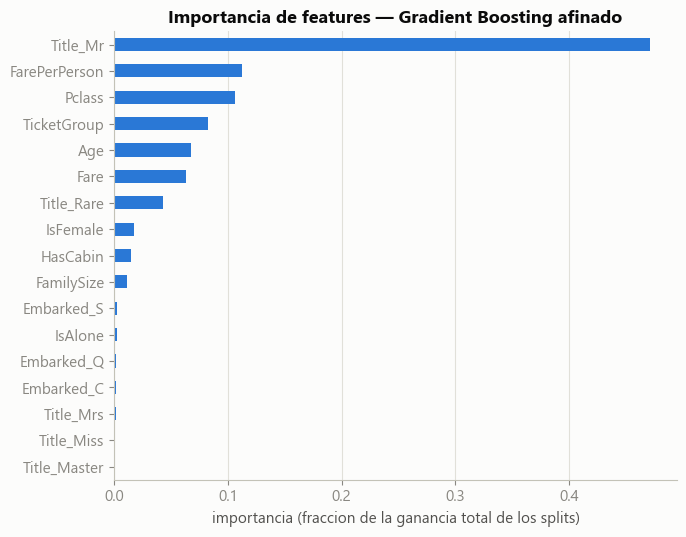

In [7]:
gb_entrenado = afinados["Gradient Boosting"].fit(X, y)
importancias = pd.Series(gb_entrenado.feature_importances_, index=X.columns).sort_values()

ax = importancias.plot(kind="barh", color=C_NO, figsize=(7, 5.5))
ax.set_title("Importancia de features — Gradient Boosting afinado")
ax.set_xlabel("importancia (fraccion de la ganancia total de los splits)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Lecturas:

- **`Title_Mr` acapara casi la mitad (0.47)** de la importancia. ¿E `IsFemale` casi cero (0.017)?!
  Es el mismo fenómeno de los coeficientes de la Fase 4: `Title_Mr` contiene "hombre adulto" —
  una vez que el modelo pregunta por Title_Mr, preguntar por IsFemale ya casi no añade nada. La
  importancia mide *uso*, no *valor intrínseco*: el sexo sigue siendo la señal reina, solo que
  entra al modelo disfrazada de título.
- El segundo escalón es economía y grupo: `FarePerPerson` (0.11, batiendo otra vez a `Fare`),
  `Pclass` (0.11), `TicketGroup` (0.08) y `Age` (0.07). Nuestras features fabricadas están entre
  las más usadas — el esfuerzo de la Fase 3 rindió.

## 5 · Último intento: ensemble de modelos

Idea final del torneo: combinar varios modelos distintos (**`VotingClassifier`**). Con
`voting="soft"` cada modelo aporta su *probabilidad* y se promedian — la esperanza es que sus
errores sean diferentes y se cancelen (la misma lógica del bagging, pero entre familias distintas).

In [8]:
svm_params = afinados["SVM (RBF)"][-1]
# probability=True calibra las probabilidades del SVM con una CV interna que es
# aleatoria -> fijamos random_state tambien aqui para que el resultado sea reproducible
voto = VotingClassifier([
    ("logistica", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ("rf",  afinados["Random Forest"]),
    ("gb",  afinados["Gradient Boosting"]),
    ("svm", make_pipeline(StandardScaler(), SVC(C=svm_params.C, gamma=svm_params.gamma,
                                                probability=True, random_state=42))),
], voting="soft")

r_voto = validacion.evaluar(voto, X, y, "Voting (log+rf+gb+svm)")

Voting (log+rf+gb+svm)         CV = 0.8417 ± 0.0136   (folds: 0.855 0.831 0.820 0.848 0.854)


**0.8417 — PEOR que el GB solo (0.8563).** Resultado honesto e instructivo: los ensembles no son
magia. Aquí fallan las dos condiciones que los hacen funcionar:

1. **Miembros de fuerza pareja**: nuestro GB está 1-2 puntos por encima del resto; promediar con
   modelos más flojos lo diluye en vez de ayudarlo.
2. **Errores diversos**: los cuatro entrenan con las MISMAS 16 features y fallan en los mismos
   pasajeros-moneda-al-aire. No hay nada que cancelar.

Se queda fuera. (En competiciones serias los ensembles ganan porque combinan modelos fuertes Y
diversos — features distintas, arquitecturas distintas. Buen tema para la Fase 7.)

## 6 · Actualizar el registro y cerrar

Apuntamos todo en el registro de experimentos — también lo que NO funcionó (el voting): dentro de
una semana, "¿probamos ya un ensemble?" debe tener respuesta escrita.

In [9]:
registro = pd.read_csv("../submissions/registro_experimentos.csv")
nuevos = pd.DataFrame([

    {"version": "v02-rf-afinado", "fecha": "2026-07-08", "features": "16 (Fase 3)",
     "modelo": "RF(depth=8, leaf=4, feat=0.5)",            "cv_media": 0.8473, "cv_std": 0.0092, "lb_publico": None},
    {"version": "v03-gb-afinado", "fecha": "2026-07-08", "features": "16 (Fase 3)",
     "modelo": "GB(lr=0.03, depth=4, n=100)",              "cv_media": 0.8563, "cv_std": 0.0245, "lb_publico": None},
    {"version": "v04-voting",     "fecha": "2026-07-08", "features": "16 (Fase 3)",
     "modelo": "Voting soft (log+rf+gb+svm) - DESCARTADO", "cv_media": 0.8417, "cv_std": 0.0136, "lb_publico": None},
])
# Idempotente: si re-ejecutamos el notebook, reemplaza estas filas en vez de duplicarlas
registro = registro[~registro["version"].isin(nuevos["version"])]
registro = pd.concat([registro, nuevos], ignore_index=True)
registro.to_csv("../submissions/registro_experimentos.csv", index=False)
registro

,version,fecha,features,modelo,cv_media,cv_std,lb_publico
0,base-mayoria,2026-07-08,-,DummyClassifier(most_frequent),0.6162,0.0023,NaN
1,base-genero,2026-07-08,IsFemale,ReglaGenero,0.7868,0.0188,0.7655
2,v01-logistica,2026-07-08,16 (Fase 3),StandardScaler+LogisticRegression,0.8328,0.0110,NaN
3,v02-rf-afinado,2026-07-08,16 (Fase 3),"RF(depth=8, leaf=4, feat=0.5)",0.8473,0.0092,NaN
4,v03-gb-afinado,2026-07-08,16 (Fase 3),"GB(lr=0.03, depth=4, n=100)",0.8563,0.0245,NaN
5,v04-voting,2026-07-08,16 (Fase 3),Voting soft (log+rf+gb+svm) - DESCARTADO,0.8417,0.0136,NaN


## 7 · Conclusiones de la Fase 5

| Puesto | Modelo | CV |
|---|---|---|
| 🥇 | **Gradient Boosting afinado** (lr=0.03, depth=4, 100 árboles) | **0.8563 ± 0.0245** |
| 🥈 | **Random Forest afinado** (depth=8, leaf=4) | 0.8473 ± 0.0092 |
| — | Voting ensemble | 0.8417 (descartado) |
| — | Mejor default (árbol podado) | 0.8417 |
| — | Baseline logística (Fase 4) | 0.8328 |

- Ideas nuevas de hoy: bagging vs boosting, hiperparámetros y `GridSearchCV`, `cross_val_predict`,
  matriz de confusión, importancia de features, voting.
- Las tres moralejas: (1) en datos pequeños gana la **suavidad** (learning rate bajo, hojas mínimas,
  profundidad capada); (2) una ventaja menor que su desviación **no es una ventaja segura** — por
  eso llevamos DOS finalistas a Kaggle; (3) nuestros errores viven donde el EDA predijo: hombres de
  1ª y mujeres de 3ª — la parte de suerte que ningún modelo va a resolver.

**Siguiente — Fase 6:** reentrenar los finalistas con el 100% del train, generar los archivos de
submission, validar su formato, subirlos a Kaggle y — el momento de la verdad — comparar el LB real
con nuestra CV.